## EXERCÍCIO - Aula 07

Treinar um modelo de regressão linear para prever os valores da coluna 'stab'.
sklearn ----> LinearRegression

Para essa tarefa é necessário que o grupo encontre as features
que possuam maior correlação linear com a variável alvo 'stab'.

Dica:
Crie uma matriz de correlação usando heatmap com o matplotlib e/ou seaborn

y ---> target ---> dados da coluna 'stab'
X ---> features ------> dataframe com as features com maior correlação linear com a coluna 'stab'
----> no mínimo 3 atributos

Métricas: Coeficiente de determinação R2 MAE MSE

Gerar os gráficos de correlação entre 'stab' e as variáveis de entrada.

Gerar o gráfico Real x Previsto



##Preparação do ambiente

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
# Algoritmo do sklearn de Regressão Linear
from sklearn.linear_model import LinearRegression

# Separação os dados de treino e teste
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test

# Métricas para regressão
# R2 ----> Coeficiente de determinação
# MAE -----> Erro médio absoluto
# MSE -----> Erro médio quadrático
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

##Carregar os dados e gerar um DataFrame

In [23]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/machine_learning_SERS_1CC/main/Data_for_UCI_named.csv')

In [24]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


##Análise Exploratória

In [25]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [26]:
# Somente estatísticas de atributos categóricos
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [27]:
# Somente estatísticas de atributos numéricos
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


## Matriz de Correlação

Coluna alvo 'stab' vs demais atributos

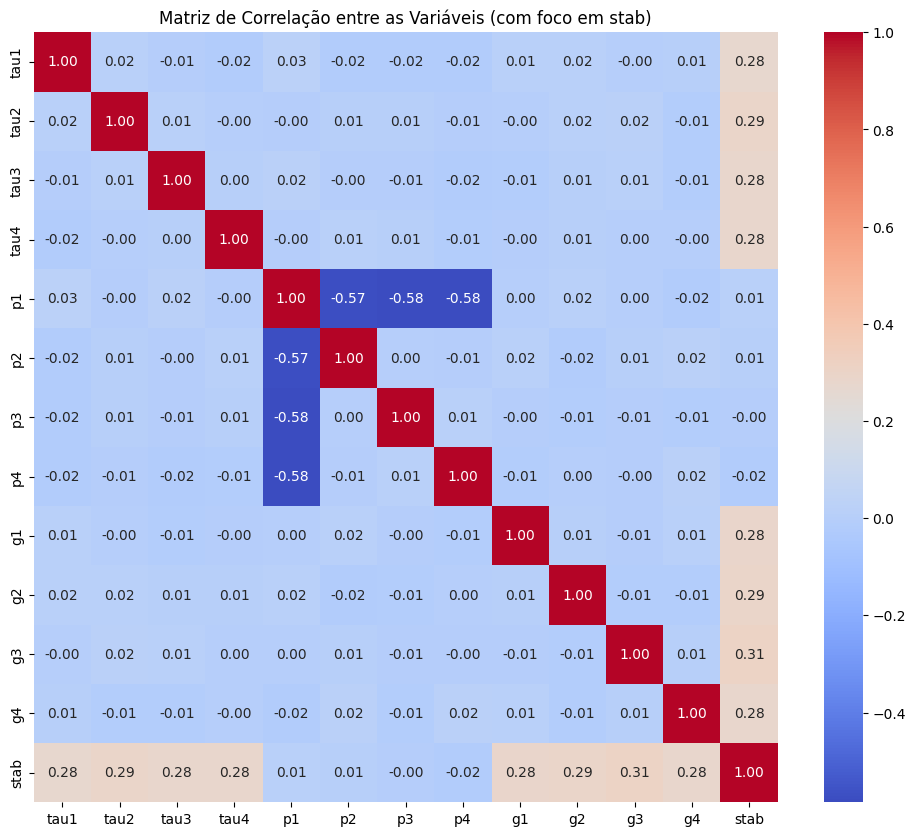

In [28]:
plt.figure(figsize=(12, 10))
sns.heatmap(dados.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação entre as Variáveis (com foco em stab)')
plt.show()

Com base na matriz de correlação, as variáveis com maior correlação linear com 'stab' são:
- `g3` (0.31)
- `tau2` (0.29)
- `g2` (0.29)

Vou utilizar `g3`, `tau2` e `g2` como features de entrada para o modelo.

## Gráficos de dispersão (scatter plots)

3 atributos escolhidos (eixo X) vs atributo alvo (eixo y)

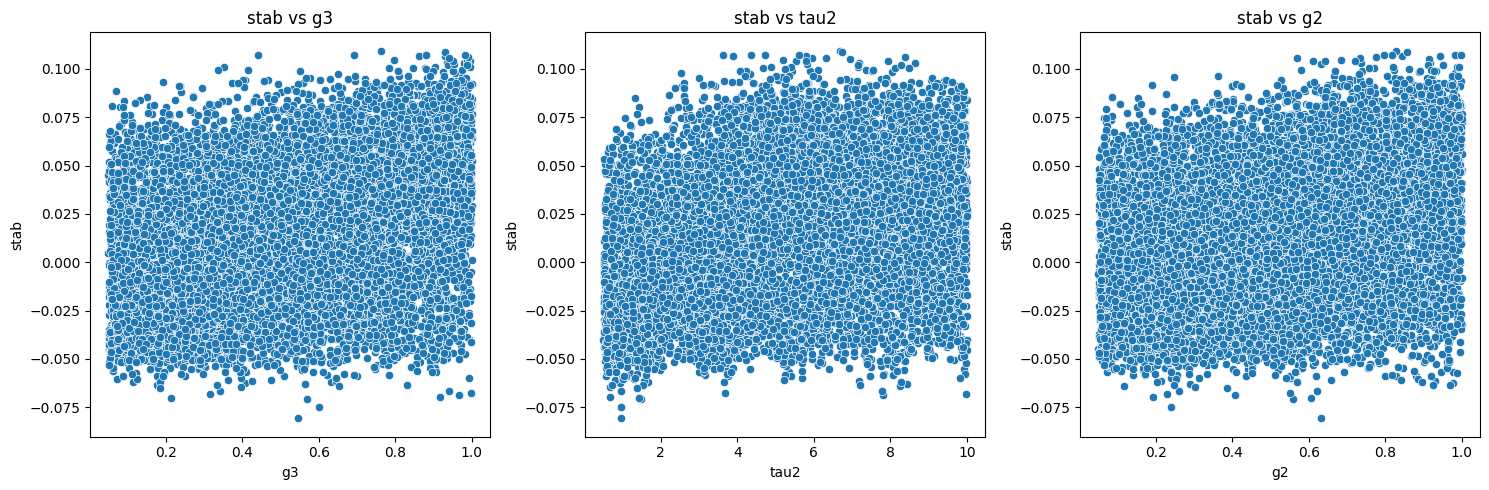

In [29]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='g3', y='stab', data=dados)
plt.title('stab vs g3')

plt.subplot(1, 3, 2)
sns.scatterplot(x='tau2', y='stab', data=dados)
plt.title('stab vs tau2')

plt.subplot(1, 3, 3)
sns.scatterplot(x='g2', y='stab', data=dados)
plt.title('stab vs g2')

plt.tight_layout()
plt.show()

## Separação de dados:

Entrada (features) ----> X

Saída (target) ----> y

In [30]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [31]:
# Features
# X
X = dados[['g3', 'tau2', 'g2']]

In [32]:
# Variável alvo (target)
# y
y = dados['stab']

##Separação de dados de treino e teste

In [33]:
# X_train, X_test, y_train, y_test
# Amostra aleatória para treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

## Treinamento e geração das previsões do modelo

In [34]:
# Instanciando o modelo de regressão linear
model = LinearRegression()

In [35]:
# Treinando o modelo
model.fit(X_train, y_train)

LinearRegression()

In [36]:
# Gerando as previsões
y_predict = model.predict(X_test)

##Avaliação do modelo

### Avaliação de um Modelo de Regressão:

Para um **melhor modelo de regressão**:
*   **R2 (Coeficiente de Determinação) precisa ser alto**: Um R2 próximo de 1 indica que o modelo explica uma grande proporção da variância na variável dependente, ajustando-se bem aos dados.
*   **Os erros (MAE, MSE) precisam ser baixos**: Valores baixos para o Erro Médio Absoluto (MAE) e o Erro Médio Quadrático (MSE) indicam que as previsões do modelo estão próximas dos valores reais.

No nosso caso:
*   **R2**: **0.27** - Valor baixo, sugerindo que o modelo explica apenas 27% da variância em 'stab'. Isso indica que o modelo linear pode não ser a melhor escolha ou que mais features são necessárias.
*   **MAE**: **0.03** - Um erro médio absoluto relativamente baixo, o que é positivo em termos da magnitude média dos desvios.
*   **MSE**: **0.00** - Um erro médio quadrático muito baixo, indicando que o modelo não tem grandes erros que seriam amplificados ao quadrado.

**Conclusão**: Embora o modelo apresente erros absolutos e quadráticos baixos, o baixo R2 aponta que ele não captura a maior parte da variabilidade da 'stab'. Isso sugere a necessidade de explorar outras features, engenharia de features ou modelos de regressão mais complexos.

In [37]:
print(f'Coeficiente de determinação R2: {r2_score(y_test, y_predict):.2f}')
print(f'Erro médio absoluto (MAE): {mean_absolute_error(y_test, y_predict):.2f}')
print(f'Erro médio quadrático (MSE): {mean_squared_error(y_test, y_predict):.2f}')

Coeficiente de determinação R2: 0.27
Erro médio absoluto (MAE): 0.03
Erro médio quadrático (MSE): 0.00


## Gráfico Real x Previsto

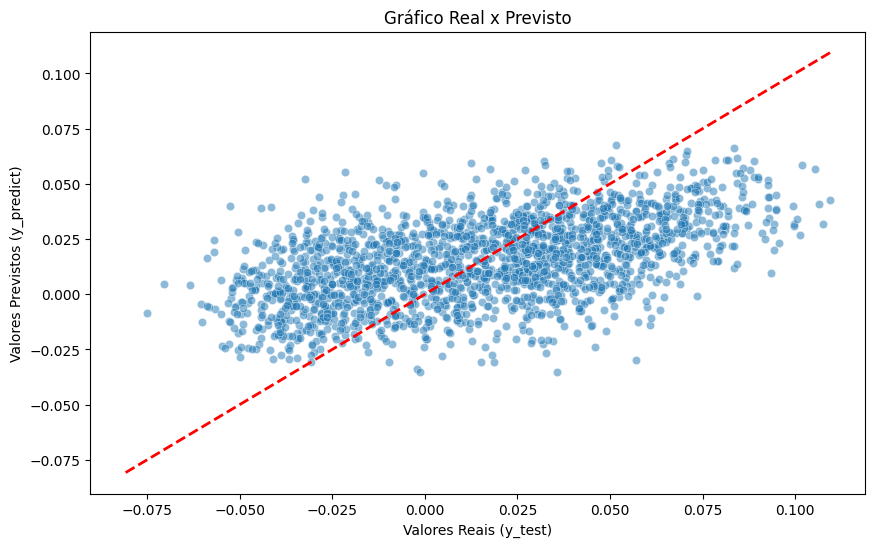

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_predict, alpha=0.5)
plt.xlabel('Valores Reais (y_test)')
plt.ylabel('Valores Previstos (y_predict)')
plt.title('Gráfico Real x Previsto')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.show()